In [58]:
%pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 📝 Introduction et Importation des données

**Étape 1 : Préparation des données (Data Wrangling & EDA de base)**
Nous allons utiliser le jeu de données *Breast Cancer*. La première étape est cruciale : séparer nos données en un jeu d'entraînement et un jeu de test, puis standardiser les valeurs pour que nos algorithmes (notamment le LASSO et les SVM) fonctionnent correctement.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
# Chargement des données
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [61]:
# Séparation Train/Test (Hold-out)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# Standardisation (ajustée sur le train, appliquée sur le train et le test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
# Reconversion en DataFrame pour garder le nom des colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Dimensions initiales : {X_train_scaled.shape}")

Dimensions initiales : (455, 30)


### 📝 L'Entonnoir de sélection (Partie 1)

**Étape 2a : Le Filtre LASSO (Régularisation L1)**
La régularisation L1 pénalise la complexité du modèle en forçant les coefficients des variables les moins utiles à tomber exactement à zéro. C'est une excellente méthode "embedded" pour faire un premier tri.

In [64]:
from sklearn.linear_model import LogisticRegression

# On utilise une régression logistique avec pénalité L1 (LASSO)
# Le paramètre C contrôle la régularisation (plus C est petit, plus la régularisation est forte)
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

/home/aptitek/Documents/Aptispace/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aptitek/Documents/Aptispace/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [65]:
# Récupération des coefficients
coefficients = lasso_model.coef_[0]

In [66]:
# Filtrage : on garde uniquement les colonnes dont le coefficient n'est pas nul
colonnes_lasso = X_train_scaled.columns[coefficients != 0]

X_train_lasso = X_train_scaled[colonnes_lasso]
print(f"Variables conservées après LASSO : {len(colonnes_lasso)} sur {len(X.columns)}")

Variables conservées après LASSO : 8 sur 30


### L'Entonnoir de sélection (Partie 2)

**Étape 2b : L'affinement avec Random Forest**
Maintenant que le bruit a été réduit, nous utilisons un algorithme non linéaire (Random Forest) pour évaluer l'importance relative des variables restantes en fonction de leur capacité à séparer les classes.

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Entraînement du Random Forest sur les données réduites par LASSO
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_lasso, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
# Récupération de l'importance des variables
importances = rf_model.feature_importances_

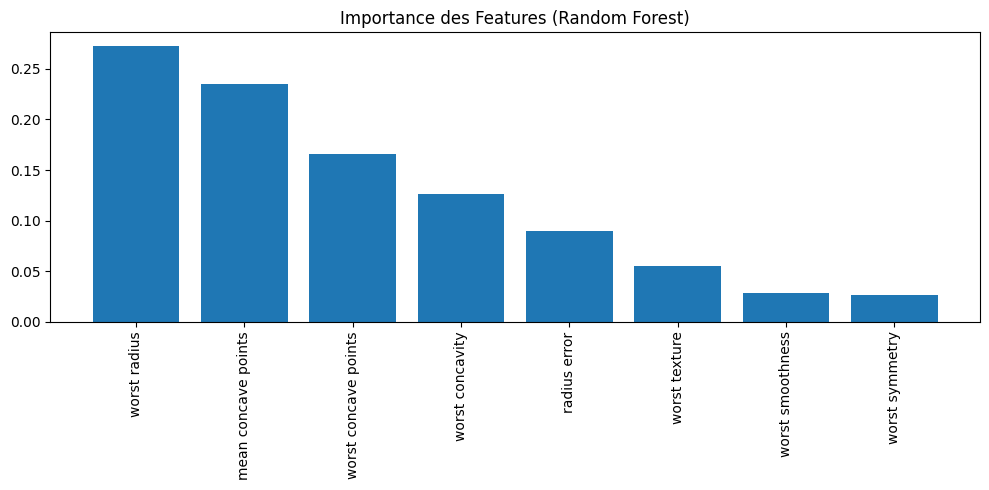

In [69]:
# Création d'un graphique pour visualiser
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
plt.title("Importance des Features (Random Forest)")
plt.bar(range(X_train_lasso.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train_lasso.shape[1]), X_train_lasso.columns[indices], rotation=90)
plt.tight_layout()
plt.show()

In [70]:
# On sélectionne le Top 5 pour la suite du TP
top_5_features = X_train_lasso.columns[indices][:5]
X_train_final = X_train_lasso[top_5_features]
print(f"Nos 5 features finales : {list(top_5_features)}")

Nos 5 features finales : ['worst radius', 'mean concave points', 'worst concave points', 'worst concavity', 'radius error']


### 📝 Cellule Markdown : Validation Croisée et Overfitting

**Étape 4 : Évaluer le modèle de façon robuste**
De retour sur nos données médicales réduites à 5 colonnes. Nous allons utiliser la validation croisée (K-Fold) pour nous assurer que notre modèle est stable et qu'il ne fait pas d'overfitting.

In [71]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Modèle SVM avec un noyau RBF (par défaut)
svm_model = SVC(kernel='rbf', random_state=42)

In [72]:
# Validation croisée à 5 plis
scores_cv = cross_val_score(svm_model, X_train_final, y_train, cv=5, scoring='accuracy')

print(f"Scores sur chaque pli : {scores_cv}")
print(f"Précision moyenne : {scores_cv.mean():.4f} (+/- {scores_cv.std() * 2:.4f})")

Scores sur chaque pli : [0.9010989  0.92307692 0.97802198 0.94505495 0.91208791]
Précision moyenne : 0.9319 (+/- 0.0545)


### 📝 L'Arène des Hyperparamètres

**Étape 5 : Grid Search**
Comment savoir quel niveau de régularisation (`C`) ou quelle taille de noyau (`gamma`) utiliser ? Nous allons tester une grille de combinaisons et laisser la machine trouver les meilleurs réglages pour nous.

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Définition de la grille des hyperparamètres à tester
param_grid = {
    'C': [0.1, 1, 10, 100],          # Régularisation (petit C = forte régularisation)
    'gamma': [1, 0.1, 0.01, 0.001],  # Portée du noyau RBF
    'kernel': ['rbf']
}

In [74]:
# Lancement du Grid Search avec validation croisée intégrée
grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5)
grid.fit(X_train_final, y_train)

print(f"Meilleurs hyperparamètres trouvés : {grid.best_params_}")

Meilleurs hyperparamètres trouvés : {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [75]:
# Évaluation finale sur notre jeu de test (laissé de côté à l'étape 1)
# N'oublions pas de réduire X_test aux 5 mêmes colonnes !
X_test_final = X_test_scaled[top_5_features]
predictions = grid.predict(X_test_final)

print("\n--- Rapport de performance final sur les données de TEST ---")
print(classification_report(y_test, predictions))


--- Rapport de performance final sur les données de TEST ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

